##**Prophet (Curve Fitting)**

### **Concept**
**Prophet** (by Meta) treats forecasting as a **curve-fitting problem** rather than looking at correlations. It decomposes the time series into:
1.  **Trend:** Non-periodic changes.
2.  **Seasonality:** Periodic patterns (e.g., Monsoon cycles).
3.  **Regressors:** External drivers like **Rainfall** and **Inflow**.



### **Hypothesis**
We test if Prophet's strong seasonality handling can capture the annual monsoon cycles better than SARIMAX, or if it over-smooths the sudden "shock" events (floods).

### **Configuration**
* **Seasonality:** Yearly = `True`.
* **Regressors:** `Rainfall` and `Inflow` added explicitly.

**Import Required libraries and Modules**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import sys
import os

**Setup & Data Loading**

In [2]:
if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_PATH = '/content/drive/MyDrive/EDI-III Project/Data/Processed Data'
else:
    BASE_PATH = '.'

file_path = os.path.join(BASE_PATH, 'Chembarambakkam.csv')
print(f"Loading data from: {file_path}")

try:
    df = pd.read_csv(file_path)
    df['Date'] = pd.to_datetime(df['Date'])
    df.set_index('Date', inplace=True)

    if df.index.duplicated().any():
        print(f"Warning: Found {df.index.duplicated().sum()} duplicate dates. Keeping the first occurrence.")
        df = df[~df.index.duplicated(keep='first')]

    df = df.asfreq('D')

    df = df.ffill()
except FileNotFoundError:
    print("Error: File not found. Please run the Data Processing script first.")
    sys.exit()


Mounted at /content/drive
Loading data from: /content/drive/MyDrive/EDI-III Project/Data/Processed Data/Chembarambakkam.csv


**Prophet Data Formatting**

In [3]:
prophet_df = df.reset_index().rename(columns={'Date': 'ds', 'Storage (mcft)': 'y'})

regressors = ['Rainfall (mm)', 'Inflow (cusecs)']
prophet_df = prophet_df[['ds', 'y'] + regressors]

**Train & Test Split Data**

In [4]:
test_days = 730
train = prophet_df.iloc[:-test_days]
test = prophet_df.iloc[-test_days:]

print(f"Training Data: {len(train)} days")
print(f"Testing Data: {len(test)} days")

print("\nTraining Prophet Model...")
m = Prophet(daily_seasonality=False, weekly_seasonality=False, yearly_seasonality=True)

m.add_regressor('Rainfall (mm)')
m.add_regressor('Inflow (cusecs)')

m.fit(train)

Training Data: 6812 days
Testing Data: 730 days

Training Prophet Model...


**Prediction or Forecasting**

In [5]:
print("Generating Forecast...")

future = test[['ds'] + regressors]

forecast = m.predict(future)

Generating Forecast...


**Evaluation of Model**

In [7]:
predictions = forecast['yhat'].values
actuals = test['y'].values

rmse = np.sqrt(mean_squared_error(actuals, predictions))
mae = mean_absolute_error(actuals, predictions)

mape = np.mean(np.abs((actuals - predictions) / (actuals + 1e-10))) * 100
r2 = r2_score(actuals, predictions)

print(f"\n{'='*30}")
print(f"MODEL E (Prophet) EVALUATION")
print(f"{'='*30}")
print(f"RMSE : {rmse:.2f} mcft")
print(f"MAE  : {mae:.2f} mcft")
print(f"MAPE : {mape:.2f} %")
print(f"R²   : {r2:.4f}")
print(f"{'='*30}")


MODEL E (Prophet) EVALUATION
RMSE : 2100.03 mcft
MAE  : 1903.84 mcft
MAPE : 82.70 %
R²   : -13.4898


**Optimizing Model**

In [8]:
from sklearn.model_selection import ParameterGrid
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_squared_error, mean_absolute_error

param_grid = {
    'changepoint_prior_scale': [0.05, 0.1, 0.5], # Default is 0.05. 0.5 is very flexible.
    'seasonality_mode': ['additive', 'multiplicative']
}

grid = ParameterGrid(param_grid)
results = []

print(f"Testing {len(grid)} combinations of parameters...")

for params in grid:
    print(f"Testing: {params}")

    m = Prophet(
        daily_seasonality=False,
        weekly_seasonality=False,
        yearly_seasonality=True,
        changepoint_prior_scale=params['changepoint_prior_scale'],
        seasonality_mode=params['seasonality_mode']
    )

    m.add_regressor('Rainfall (mm)')
    m.add_regressor('Inflow (cusecs)')

    m.fit(train)

    future = test[['ds', 'Rainfall (mm)', 'Inflow (cusecs)']]
    forecast = m.predict(future)

    predictions = forecast['yhat'].values
    actuals = test['y'].values
    rmse = np.sqrt(mean_squared_error(actuals, predictions))

    results.append({
        'params': params,
        'rmse': rmse,
        'preds': predictions
    })
    print(f"  -> RMSE: {rmse:.2f}")

Testing 6 combinations of parameters...
Testing: {'changepoint_prior_scale': 0.05, 'seasonality_mode': 'additive'}
  -> RMSE: 2100.03
Testing: {'changepoint_prior_scale': 0.05, 'seasonality_mode': 'multiplicative'}
  -> RMSE: 2065.87
Testing: {'changepoint_prior_scale': 0.1, 'seasonality_mode': 'additive'}
  -> RMSE: 2298.73
Testing: {'changepoint_prior_scale': 0.1, 'seasonality_mode': 'multiplicative'}
  -> RMSE: 2273.30
Testing: {'changepoint_prior_scale': 0.5, 'seasonality_mode': 'additive'}
  -> RMSE: 2405.82
Testing: {'changepoint_prior_scale': 0.5, 'seasonality_mode': 'multiplicative'}
  -> RMSE: 2366.29


**Choosing Best Model**

In [9]:
best_result = min(results, key=lambda x: x['rmse'])
best_params = best_result['params']
best_rmse = best_result['rmse']
best_preds = best_result['preds']

best_model = Prophet(
    daily_seasonality=False,
    weekly_seasonality=False,
    yearly_seasonality=True,
    changepoint_prior_scale=best_params['changepoint_prior_scale'],
    seasonality_mode=best_params['seasonality_mode']
)

best_model.add_regressor('Rainfall (mm)')
best_model.add_regressor('Inflow (cusecs)')

best_model.fit(train)

future_best = test[['ds', 'Rainfall (mm)', 'Inflow (cusecs)']]
best_forecast = best_model.predict(future_best)


print(f"\n{'='*30}")
print(f"🚀 OPTIMIZED PROPHET RESULTS")
print(f"{'='*30}")
print(f"Best Params: {best_params}")
print(f"Best RMSE:   {best_rmse:.2f} mcft")
print(f" (Previous RMSE was ~2093.15 mcft)")


🚀 OPTIMIZED PROPHET RESULTS
Best Params: {'changepoint_prior_scale': 0.05, 'seasonality_mode': 'multiplicative'}
Best RMSE:   2065.87 mcft
 (Previous RMSE was ~2093.15 mcft)


**Visualization**

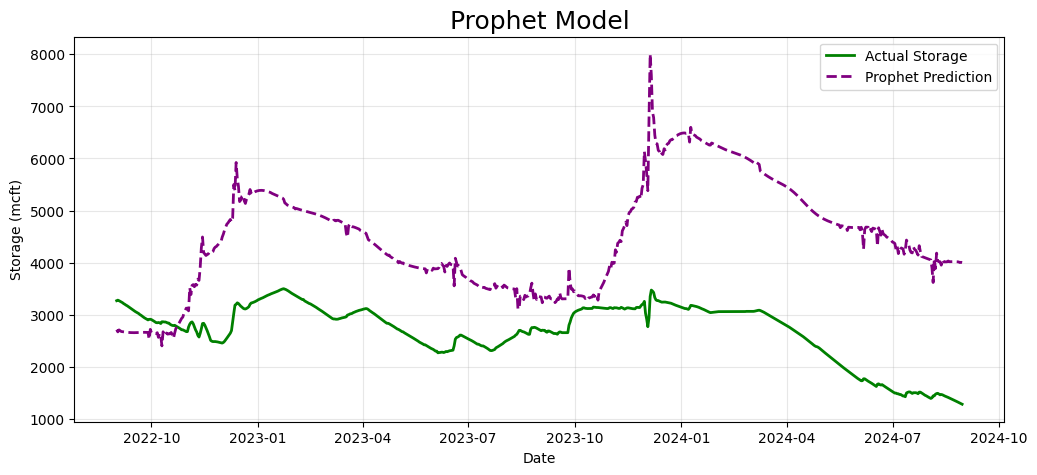

In [13]:
plt.figure(figsize=(12, 5))
plt.plot(test['ds'], test['y'], label='Actual Storage', color='green', linewidth=2)
plt.plot(test['ds'], best_preds, label='Prophet Prediction', color='purple', linestyle='--', linewidth=2)
plt.title(f"Prophet Model", fontsize=18)
plt.xlabel('Date')
plt.ylabel('Storage (mcft)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


Optimized Prophet Model Components:
1. Trend: Notice if it reacts faster to changes.
2. Yearly: The seasonal impact.
3. Extra Regressors: Impact of Rain/Inflow.


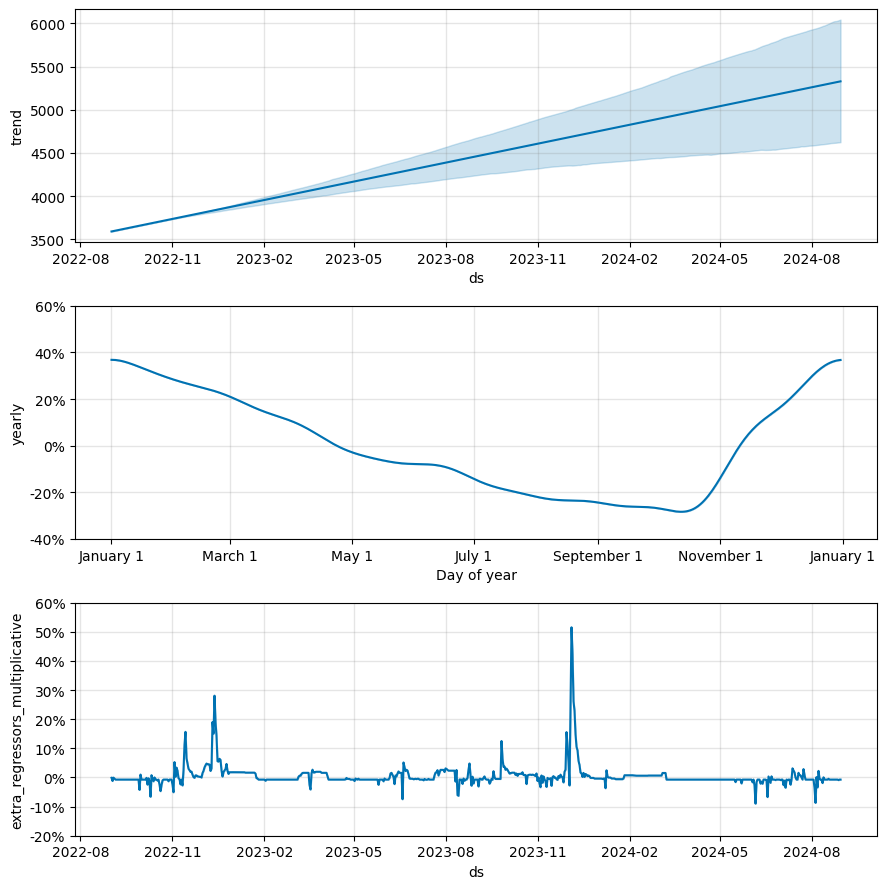

In [11]:
print("\nOptimized Prophet Model Components:")
print("1. Trend: Notice if it reacts faster to changes.")
print("2. Yearly: The seasonal impact.")
print("3. Extra Regressors: Impact of Rain/Inflow.")

fig2 = best_model.plot_components(best_forecast)

plt.show()